# Policing Equity

This notebook prepares the selected policing incident dataset, engineers features, reduces dimensionality, clusters incidents, and saves report-ready tables and figures.

**Selected file**

```text
cpe-data/Dept_49-00081/49-00081_Incident-Reports_2012_to_May_2015.csv
```

The notebook intentionally excludes row identifiers and full street addresses from clustering, because they do not describe general incident similarity and can create very high-dimensional encodings.

In [1]:
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Configuration

In [2]:
DATA_PATH = Path("49-00081_Incident-Reports_2012_to_May_2015.csv")
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

RANDOM_STATE = 42
SVD_COMPONENTS = 50
BEST_K = 4
K_RANGE = range(2, 11)
EVAL_SAMPLE_SIZE = 30_000
SILHOUETTE_SAMPLE_SIZE = 5_000
PLOT_SAMPLE_SIZE = 100_000

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Helper functions

In [3]:
REQUIRED_COLUMNS = [
    "INCIDENT_UNIQUE_IDENTIFIER",
    "INCIDENT_REASON",
    "INCIDENT_REASON_DESCRIPTION",
    "INCIDENT_DAY",
    "INCIDENT_DATE",
    "INCIDENT_TIME",
    "LOCATION_DISTRICT",
    "LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION",
    "DISPOSITION",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
]

MODEL_FEATURES = [
    "incident_reason_simple",
    "INCIDENT_REASON_DESCRIPTION",
    "incident_year",
    "incident_month",
    "incident_dayofweek",
    "incident_time_minutes",
    "is_weekend",
    "time_period",
    "LOCATION_DISTRICT",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
    "lat_bin",
    "lon_bin",
    "disposition_simple",
]

NUMERIC_FEATURES = [
    "incident_year",
    "incident_month",
    "incident_dayofweek",
    "incident_time_minutes",
    "is_weekend",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
    "lat_bin",
    "lon_bin",
]

CATEGORICAL_FEATURES = [
    "incident_reason_simple",
    "INCIDENT_REASON_DESCRIPTION",
    "time_period",
    "LOCATION_DISTRICT",
    "disposition_simple",
]


def validate_columns(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def save_current_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def clean_text(series: pd.Series) -> pd.Series:
    """Clean text values without using pd.NA.

    Using np.nan avoids pandas' "boolean value of NA is ambiguous" errors
    in later boolean operations and plotting.
    """
    cleaned = series.astype("object").where(series.notna(), np.nan)
    cleaned = cleaned.astype(str).str.strip().str.lower()
    cleaned = cleaned.replace(["nan", "none", "<na>", "unknown", "unk", ""], np.nan)
    return cleaned.astype("object")


def minutes_to_time(minutes: float) -> str:
    if pd.isna(minutes):
        return "missing"
    hours = int(minutes // 60)
    mins = int(minutes % 60)
    return f"{hours:02d}:{mins:02d}"


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)


def top_values(series: pd.Series, n: int = 3) -> str:
    shares = series.fillna("missing").value_counts(normalize=True).head(n)
    return "; ".join([f"{idx}: {val:.1%}" for idx, val in shares.items()])


def sample_dataframe(df: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    if len(df) <= max_rows:
        return df.copy()
    return df.sample(n=max_rows, random_state=RANDOM_STATE).copy()


def sample_array(X: np.ndarray, max_rows: int) -> np.ndarray:
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

## 3. Load and inspect the dataset

In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)
validate_columns(df, REQUIRED_COLUMNS)

print("Shape:", df.shape)
df.head()

Shape: (394236, 11)


,INCIDENT_UNIQUE_IDENTIFIER,INCIDENT_REASON,INCIDENT_REASON_DESCRIPTION,INCIDENT_DAY,INCIDENT_DATE,INCIDENT_TIME,LOCATION_DISTRICT,DISPOSITION,LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION,LOCATION_LONGITUDE,LOCATION_LATITUDE
0,IncidntNum,Category,Descript,DayOfWeek,Date,Time,PdDistrict,Resolution,Address,X,Y
1,120000790,SUSPICIOUS OCC,INVESTIGATIVE DETENTION,Sunday,1/1/12,4:50,SOUTHERN,NONE,0 Block of 7TH ST,-122.4122725,37.78020391
2,120004770,NON-CRIMINAL,LOST PROPERTY,Sunday,1/1/12,1:25,MISSION,NONE,2800 Block of MISSION ST,-122.418434,37.75141993
3,120000712,ASSAULT,"BATTERY, FORMER SPOUSE OR DATING RELATIONSHIP",Sunday,1/1/12,3:35,INGLESIDE,"ARREST, BOOKED",2000 Block of SAN JOSE AV,-122.4439879,37.72397891
4,120064611,NON-CRIMINAL,LOST PROPERTY,Sunday,1/1/12,22:00,INGLESIDE,NONE,300 Block of HEARST AV,-122.4454574,37.73064873


In [5]:
column_groups = {
    "INCIDENT_UNIQUE_IDENTIFIER": "id_like",
    "INCIDENT_REASON": "incident_type",
    "INCIDENT_REASON_DESCRIPTION": "incident_type",
    "INCIDENT_DAY": "date_time",
    "INCIDENT_DATE": "date_time",
    "INCIDENT_TIME": "date_time",
    "LOCATION_DISTRICT": "geographic",
    "LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION": "geographic",
    "LOCATION_LONGITUDE": "geographic",
    "LOCATION_LATITUDE": "geographic",
    "DISPOSITION": "outcome",
}

column_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_share": df.isna().mean().values,
    "unique_values": df.nunique(dropna=True).values,
})
column_summary["column_group"] = column_summary["column"].map(column_groups).fillna("other")
column_summary = column_summary.sort_values(["column_group", "column"])

column_summary.to_csv(OUTPUT_DIR / "column_summary.csv", index=False)
column_summary

,column,dtype,missing_share,unique_values,column_group
4,INCIDENT_DATE,str,0.0,1379,date_time
3,INCIDENT_DAY,str,0.0,8,date_time
5,INCIDENT_TIME,str,0.0,1440,date_time
6,LOCATION_DISTRICT,str,0.0,11,geographic
8,LOCATION_FULL_STREET_ADDRESS_OR_INTERSECTION,str,0.0,19777,geographic
10,LOCATION_LATITUDE,str,0.0,25244,geographic
9,LOCATION_LONGITUDE,str,0.0,24980,geographic
0,INCIDENT_UNIQUE_IDENTIFIER,str,0.0,314745,id_like
1,INCIDENT_REASON,str,0.0,40,incident_type
2,INCIDENT_REASON_DESCRIPTION,str,0.0,833,incident_type


## 4. Cleaning and feature engineering

The ID column and full street-address column are not used as modelling features. The coordinates and district preserve geographic information with lower dimensionality.

In [6]:
df_clean = df.copy()

# Removes repeated header rows if present.
header_like = (
    df_clean["INCIDENT_UNIQUE_IDENTIFIER"].astype(str).str.upper().eq("INCIDENT_UNIQUE_IDENTIFIER")
    | df_clean["INCIDENT_REASON"].astype(str).str.upper().isin(["INCIDENT_REASON", "CATEGORY"])
)
df_clean = df_clean.loc[~header_like].reset_index(drop=True)

# Cleans text columns.
for col in ["INCIDENT_REASON", "INCIDENT_REASON_DESCRIPTION", "INCIDENT_DAY", "LOCATION_DISTRICT", "DISPOSITION"]:
    df_clean[col] = clean_text(df_clean[col])

# Coordinates must be numeric, not one-hot encoded categories.
df_clean["LOCATION_LONGITUDE"] = pd.to_numeric(df_clean["LOCATION_LONGITUDE"], errors="coerce")
df_clean["LOCATION_LATITUDE"] = pd.to_numeric(df_clean["LOCATION_LATITUDE"], errors="coerce")

# Dates features.
incident_date = pd.to_datetime(df_clean["INCIDENT_DATE"], errors="coerce")
df_clean["incident_year"] = incident_date.dt.year
df_clean["incident_month"] = incident_date.dt.month
df_clean["incident_dayofweek"] = incident_date.dt.dayofweek

# Times as minutes after midnight.
incident_time = pd.to_datetime(df_clean["INCIDENT_TIME"], format="%H:%M", errors="coerce")
df_clean["incident_time_minutes"] = incident_time.dt.hour * 60 + incident_time.dt.minute

# Additional engineered features.
df_clean["is_weekend"] = (
    df_clean["incident_dayofweek"]
    .fillna(-1)
    .isin([5, 6])
    .astype(int)
)

time_period = pd.cut(
    df_clean["incident_time_minutes"],
    bins=[-1, 359, 719, 1079, 1439],
    labels=["night", "morning", "afternoon", "evening"],
)
df_clean["time_period"] = time_period.astype("object").where(time_period.notna(), "missing")

df_clean["lat_bin"] = df_clean["LOCATION_LATITUDE"].round(2)
df_clean["lon_bin"] = df_clean["LOCATION_LONGITUDE"].round(2)
df_clean["incident_reason_simple"] = clean_text(df_clean["INCIDENT_REASON"])
df_clean["disposition_simple"] = clean_text(df_clean["DISPOSITION"])

X_raw = df_clean[MODEL_FEATURES].copy()
X_raw.head()

/tmp/ipykernel_19377/1067878274.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  incident_date = pd.to_datetime(df_clean["INCIDENT_DATE"], errors="coerce")


,incident_reason_simple,INCIDENT_REASON_DESCRIPTION,incident_year,incident_month,incident_dayofweek,incident_time_minutes,is_weekend,time_period,LOCATION_DISTRICT,LOCATION_LONGITUDE,LOCATION_LATITUDE,lat_bin,lon_bin,disposition_simple
0,suspicious occ,investigative detention,2012,1,6,290,1,night,southern,-122.412273,37.780204,37.78,-122.41,NaN
1,non-criminal,lost property,2012,1,6,85,1,night,mission,-122.418434,37.751420,37.75,-122.42,NaN
2,assault,"battery, former spouse or dating relationship",2012,1,6,215,1,night,ingleside,-122.443988,37.723979,37.72,-122.44,"arrest, booked"
3,non-criminal,lost property,2012,1,6,1320,1,evening,ingleside,-122.445457,37.730649,37.73,-122.45,NaN
4,non-criminal,"aided case, mental disturbed",2012,1,6,550,1,morning,tenderloin,-122.415067,37.783563,37.78,-122.42,psychopathic case


In [7]:
feature_summary = pd.DataFrame({
    "column": X_raw.columns,
    "dtype": X_raw.dtypes.astype(str).values,
    "missing_values": X_raw.isna().sum().values,
    "missing_share": X_raw.isna().mean().values,
    "unique_values": X_raw.nunique(dropna=True).values,
}).sort_values("unique_values", ascending=False)

feature_summary.to_csv(OUTPUT_DIR / "feature_summary.csv", index=False)
X_raw.to_csv(OUTPUT_DIR / "policing_equity_features.csv", index=False)
feature_summary

,column,dtype,missing_values,missing_share,unique_values
10,LOCATION_LATITUDE,float64,0,0.000000,25243
9,LOCATION_LONGITUDE,float64,0,0.000000,24979
5,incident_time_minutes,int32,0,0.000000,1439
1,INCIDENT_REASON_DESCRIPTION,object,0,0.000000,832
0,incident_reason_simple,object,0,0.000000,39
13,disposition_simple,object,248658,0.630735,16
12,lon_bin,float64,0,0.000000,15
11,lat_bin,float64,0,0.000000,12
3,incident_month,int32,0,0.000000,12
8,LOCATION_DISTRICT,object,0,0.000000,10


## 5. Sparse preprocessing

Categorical variables are one-hot encoded as a sparse matrix. This avoids the memory error caused by dense one-hot encoding.

In [8]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    sparse_threshold=1.0,
)

X_processed = preprocessor.fit_transform(X_raw)

print("Processed shape:", X_processed.shape)
print("Processed type:", type(X_processed))

Processed shape: (394235, 910)
Processed type: <class 'scipy.sparse._csr.csr_matrix'>


## 6. Dimensionality reduction

`TruncatedSVD` is used instead of regular PCA because the encoded data is sparse.

In [9]:
n_components = min(SVD_COMPONENTS, X_processed.shape[1] - 1)
svd_model = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_svd = svd_model.fit_transform(X_processed)

svd_df = pd.DataFrame({
    "SVD1": X_svd[:, 0],
    "SVD2": X_svd[:, 1],
})

variance_df = pd.DataFrame({
    "component": np.arange(1, n_components + 1),
    "explained_variance_ratio": svd_model.explained_variance_ratio_,
    "cumulative_explained_variance": svd_model.explained_variance_ratio_.cumsum(),
})

variance_df.to_csv(OUTPUT_DIR / "svd_explained_variance.csv", index=False)
pd.DataFrame(X_svd, columns=[f"SVD_{i + 1}" for i in range(X_svd.shape[1])]).to_csv(
    OUTPUT_DIR / "svd_components.csv", index=False
)

print("SVD shape:", X_svd.shape)
print("Total explained variance:", variance_df["explained_variance_ratio"].sum())
variance_df.tail()

SVD shape: (394235, 50)
Total explained variance: 0.9526729689913723


,component,explained_variance_ratio,cumulative_explained_variance
45,46,0.001087,0.948692
46,47,0.001060,0.949751
47,48,0.001020,0.950771
48,49,0.000963,0.951734
49,50,0.000939,0.952673


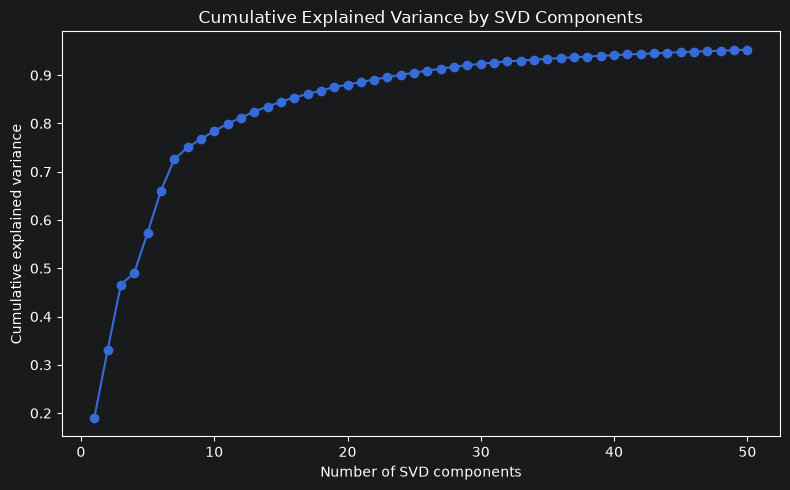

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(variance_df["component"], variance_df["cumulative_explained_variance"], marker="o")
plt.title("Cumulative Explained Variance by SVD Components")
plt.xlabel("Number of SVD components")
plt.ylabel("Cumulative explained variance")
save_current_figure("svd_cumulative_explained_variance.png")

## 7. Clustering

MiniBatch K-Means is used because the dataset is large. The final cluster number is set in `BEST_K` and can be changed after reviewing the evaluation table and plots.

In [11]:
X_eval = sample_array(X_svd, EVAL_SAMPLE_SIZE)
cluster_eval_rows = []

for k in K_RANGE:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init=10,
    )
    labels = model.fit_predict(X_eval)
    sil_sample = min(SILHOUETTE_SAMPLE_SIZE, X_eval.shape[0])

    cluster_eval_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(
            X_eval,
            labels,
            sample_size=sil_sample,
            random_state=RANDOM_STATE,
        ),
        "davies_bouldin_score": davies_bouldin_score(X_eval, labels),
        "inertia": model.inertia_,
    })

cluster_eval = pd.DataFrame(cluster_eval_rows)
cluster_eval.to_csv(OUTPUT_DIR / "cluster_evaluation.csv", index=False)
cluster_eval

,k,silhouette_score,davies_bouldin_score,inertia
0,2,0.150149,2.456727,315583.835833
1,3,0.155076,2.069610,276704.706287
2,4,0.164467,1.839503,248063.629330
3,5,0.120140,2.121526,235608.498458
4,6,0.115241,2.247680,229113.065485
5,7,0.113065,2.173594,222685.011417
6,8,0.094889,2.576430,220273.969905
7,9,0.102164,2.226469,208269.435304
8,10,0.102426,2.200069,205788.758548


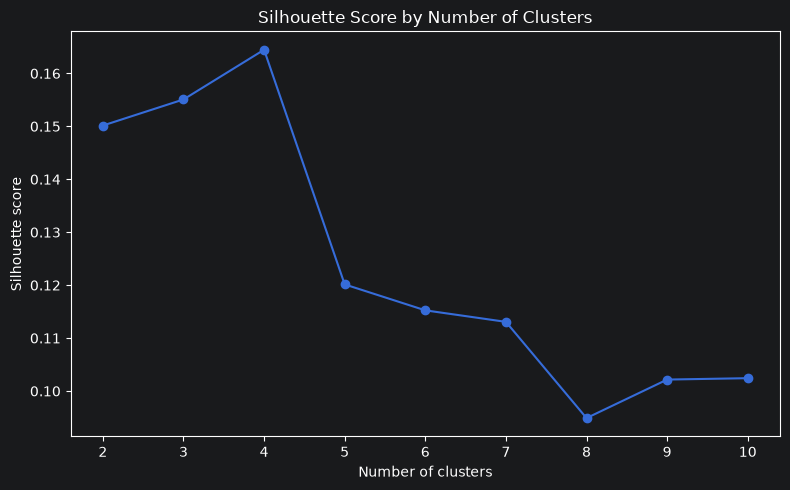

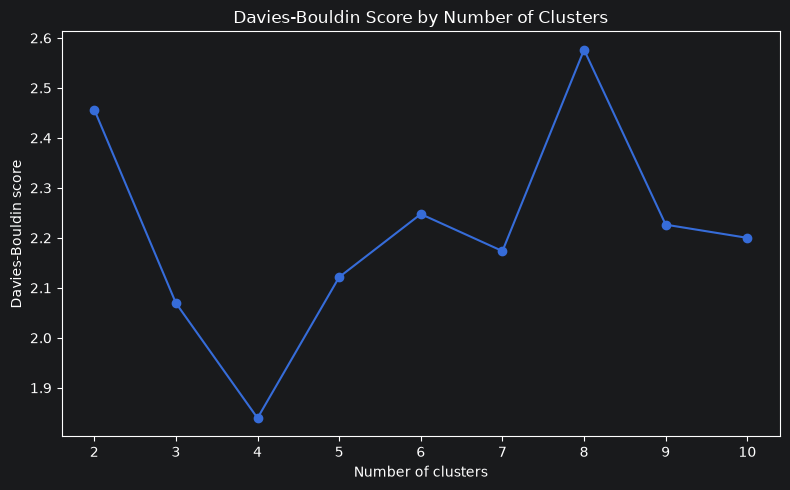

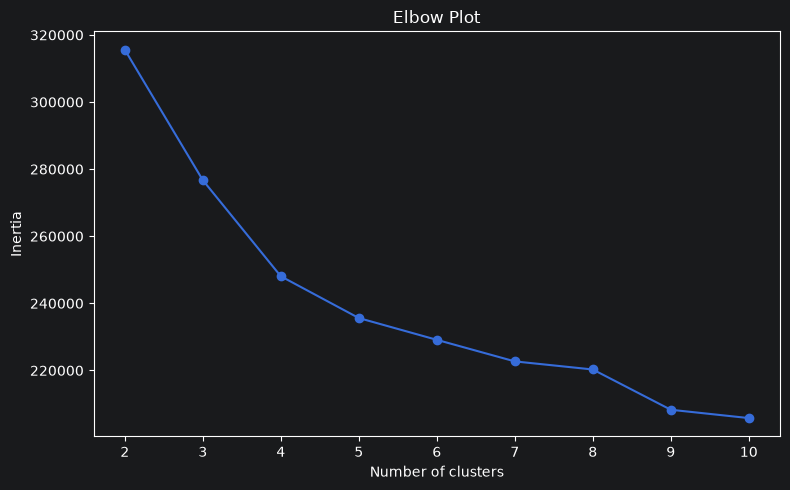

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_eval["k"], cluster_eval["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
save_current_figure("silhouette_by_k.png")

plt.figure(figsize=(8, 5))
plt.plot(cluster_eval["k"], cluster_eval["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Davies-Bouldin score")
save_current_figure("davies_bouldin_by_k.png")

plt.figure(figsize=(8, 5))
plt.plot(cluster_eval["k"], cluster_eval["inertia"], marker="o")
plt.title("Elbow Plot")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
save_current_figure("elbow_plot.png")

In [13]:
final_model = MiniBatchKMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=10,
)
cluster_labels = final_model.fit_predict(X_svd)

df_clustered = df_clean.copy()
df_clustered["cluster"] = cluster_labels
svd_df["cluster"] = cluster_labels

cluster_counts = df_clustered["cluster"].value_counts().sort_index().reset_index()
cluster_counts.columns = ["cluster", "number_of_incidents"]
cluster_counts["share_of_total"] = (cluster_counts["number_of_incidents"] / len(df_clustered)).round(4)

cluster_counts.to_csv(OUTPUT_DIR / "cluster_counts.csv", index=False)
cluster_counts

,cluster,number_of_incidents,share_of_total
0,0,80262,0.2036
1,1,81270,0.2061
2,2,96068,0.2437
3,3,136635,0.3466


## 8. Cluster interpretation

In [14]:
numeric_profile_cols = [
    "incident_year",
    "incident_month",
    "incident_dayofweek",
    "incident_time_minutes",
    "LOCATION_LONGITUDE",
    "LOCATION_LATITUDE",
]

numeric_cluster_summary = (
    df_clustered
    .groupby("cluster")[numeric_profile_cols]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
numeric_cluster_summary.to_csv(OUTPUT_DIR / "numeric_cluster_summary.csv")
numeric_cluster_summary

incident_year                     incident_month                 \
                 mean  median   min   max           mean median min max   
cluster                                                                   
0             2013.67  2014.0  2012  2015           6.00    6.0   1  12   
1             2013.67  2014.0  2012  2015           6.03    6.0   1  12   
2             2013.66  2014.0  2012  2015           6.19    6.0   1  12   
3             2013.66  2014.0  2012  2015           6.25    6.0   1  12   

        incident_dayofweek         ... incident_time_minutes        \
                      mean median  ...                   min   max   
cluster                            ...                               
0                     2.66    3.0  ...                     1  1439   
1                     2.04    2.0  ...                     1  1439   
2                     5.49    5.0  ...                     1  1439   
3                     2.06    2.0  ...                     1  1439   

        LOCATION_LONGITUDE                         LOCATION_LATITUDE         \
                      mean  median     min     max              mean median   
cluster                                                                       
0                  -122.43 -122.43 -122.51 -122.37             37.73  37.73   
1                  -122.44 -122.43 -122.51 -122.38             37.77  37.78   
2                  -122.42 -122.41 -122.51 -122.37             37.77  37.78   
3                  -122.41 -122.41 -122.46 -122.37             37.78  37.78   

                       
           min    max  
cluster                
0        37.71  37.76  
1        37.74  37.81  
2        37.72  37.82  
3        37.74  37.82  

[4 rows x 24 columns]

In [15]:
cluster_interpretation = []

for cluster_id, group in df_clustered.groupby("cluster"):
    cluster_interpretation.append({
        "cluster": cluster_id,
        "number_of_incidents": len(group),
        "share_of_total": round(len(group) / len(df_clustered) * 100, 2),
        "top_incident_reasons": top_values(group["incident_reason_simple"]),
        "top_reason_descriptions": top_values(group["INCIDENT_REASON_DESCRIPTION"]),
        "top_days": top_values(group["INCIDENT_DAY"]),
        "top_time_periods": top_values(group["time_period"]),
        "top_districts": top_values(group["LOCATION_DISTRICT"]),
        "top_dispositions": top_values(group["disposition_simple"]),
        "avg_incident_time": minutes_to_time(group["incident_time_minutes"].mean()),
        "avg_latitude": round(group["LOCATION_LATITUDE"].mean(), 5),
        "avg_longitude": round(group["LOCATION_LONGITUDE"].mean(), 5),
    })

cluster_interpretation_df = pd.DataFrame(cluster_interpretation)
cluster_interpretation_df.to_csv(OUTPUT_DIR / "final_cluster_summary_for_report.csv", index=False)

df_clustered.to_csv(OUTPUT_DIR / "policing_equity_clustered.csv", index=False)
svd_df.to_csv(OUTPUT_DIR / "svd_2d_coordinates.csv", index=False)

cluster_interpretation_df

,cluster,number_of_incidents,share_of_total,top_incident_reasons,top_reason_descriptions,top_days,top_time_periods,top_districts,top_dispositions,avg_incident_time,avg_latitude,avg_longitude
0,0,80262,20.36,other offenses: 17.7%; larceny/theft: 13.8%; n...,"stolen automobile: 5.7%; drivers license, susp...",friday: 18.2%; wednesday: 16.7%; thursday: 16.1%,evening: 34.5%; afternoon: 34.3%; morning: 20.1%,ingleside: 39.5%; bayview: 29.6%; taraval: 24.1%,"missing: 62.3%; arrest, booked: 21.3%; arrest,...",14:19,37.72948,-122.42933
1,1,81270,20.61,larceny/theft: 18.0%; non-criminal: 15.5%; oth...,grand theft from locked auto: 6.1%; aided case...,monday: 20.1%; wednesday: 20.1%; friday: 20.0%,night: 36.0%; morning: 33.0%; afternoon: 21.5%,richmond: 19.0%; park: 17.3%; mission: 16.8%,"missing: 63.9%; arrest, booked: 22.3%; arrest,...",08:41,37.77470,-122.44044
2,2,96068,24.37,larceny/theft: 24.8%; non-criminal: 13.0%; oth...,grand theft from locked auto: 8.5%; lost prope...,saturday: 51.2%; sunday: 48.8%,afternoon: 32.2%; evening: 32.1%; night: 19.1%,southern: 21.7%; mission: 15.6%; northern: 14.3%,"missing: 63.9%; arrest, booked: 24.0%; arrest,...",13:24,37.77482,-122.41909
3,3,136635,34.66,larceny/theft: 28.4%; non-criminal: 12.6%; oth...,grand theft from locked auto: 10.4%; aided cas...,friday: 21.8%; wednesday: 20.2%; thursday: 19.7%,evening: 45.0%; afternoon: 40.1%; morning: 14.2%,southern: 33.7%; central: 18.1%; mission: 14.2%,"missing: 62.4%; arrest, booked: 25.5%; arrest,...",16:43,37.78085,-122.41163


## 9. Final visualizations

Legends for stacked bar charts are placed outside the plot area. Incident reasons are reduced to top categories + `other` to keep the figure readable.

In [16]:
def plot_stacked_distribution(
    data: pd.DataFrame,
    row_col: str,
    category_col: str,
    title: str,
    filename: str,
    top_n: int | None = 10,
    normalize: bool = True,
    legend_title: str | None = None,
) -> pd.DataFrame:
    plot_df = data[[row_col, category_col]].copy()
    plot_df[category_col] = plot_df[category_col].fillna("missing").astype(str)

    if top_n is not None:
        top_categories = plot_df[category_col].value_counts().head(top_n).index
        keep_mask = plot_df[category_col].isin(top_categories).fillna(False)
        plot_df[category_col] = plot_df[category_col].where(keep_mask, "other")

    table = pd.crosstab(plot_df[row_col], plot_df[category_col], normalize="index" if normalize else False)
    table = table.round(3)

    ax = table.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title(title)
    plt.xlabel(row_col.replace("_", " ").title())
    plt.ylabel("Share within cluster" if normalize else "Number of incidents")

    ax.legend(
        title=legend_title or category_col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
    )

    save_current_figure(filename)
    return table

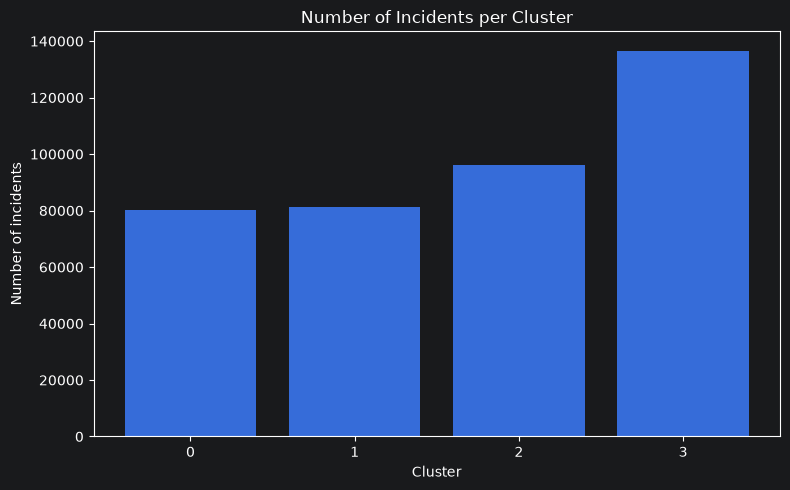

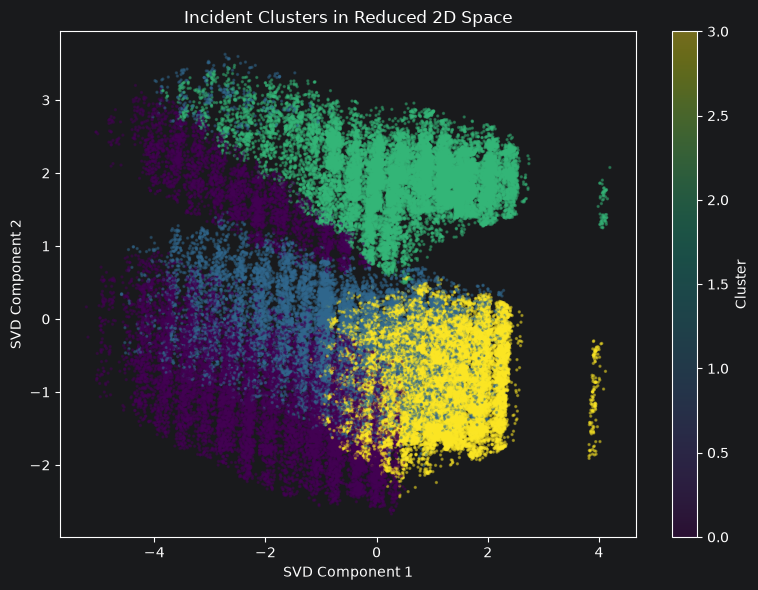

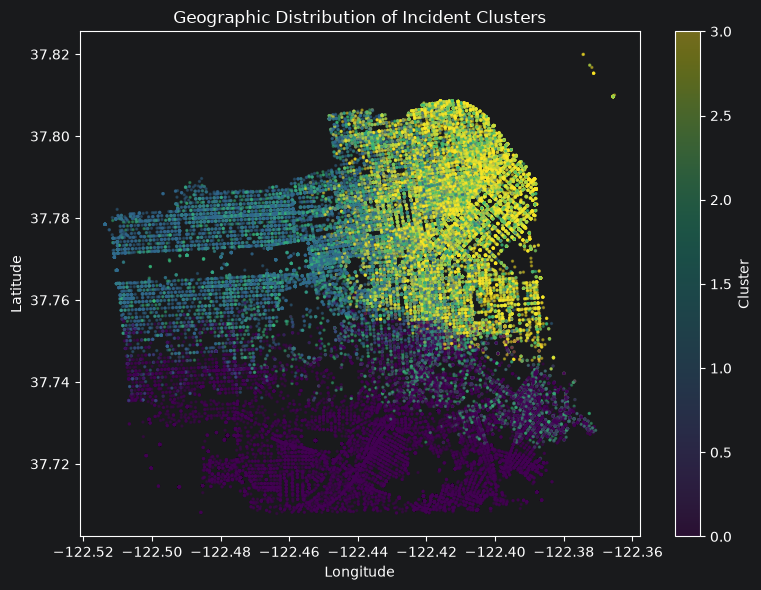

In [17]:
# Number of incidents per cluster
plt.figure(figsize=(8, 5))
plt.bar(cluster_counts["cluster"].astype(str), cluster_counts["number_of_incidents"])
plt.title("Number of Incidents per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of incidents")
save_current_figure("incidents_per_cluster.png")

# 2D SVD cluster plot
svd_plot_df = sample_dataframe(svd_df, PLOT_SAMPLE_SIZE)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    svd_plot_df["SVD1"],
    svd_plot_df["SVD2"],
    c=svd_plot_df["cluster"],
    s=2,
    alpha=0.4,
)
plt.title("Incident Clusters in Reduced 2D Space")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.colorbar(scatter, label="Cluster")
save_current_figure("svd_clusters_2d.png")

# Geographic plot
geo_plot_df = df_clustered.dropna(subset=["LOCATION_LONGITUDE", "LOCATION_LATITUDE"])
geo_plot_df = geo_plot_df[
    geo_plot_df["LOCATION_LONGITUDE"].between(-180, 180)
    & geo_plot_df["LOCATION_LATITUDE"].between(-90, 90)
]
geo_plot_df = sample_dataframe(geo_plot_df, PLOT_SAMPLE_SIZE)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    geo_plot_df["LOCATION_LONGITUDE"],
    geo_plot_df["LOCATION_LATITUDE"],
    c=geo_plot_df["cluster"],
    s=2,
    alpha=0.4,
)
plt.title("Geographic Distribution of Incident Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(scatter, label="Cluster")
save_current_figure("geographic_cluster_distribution.png")

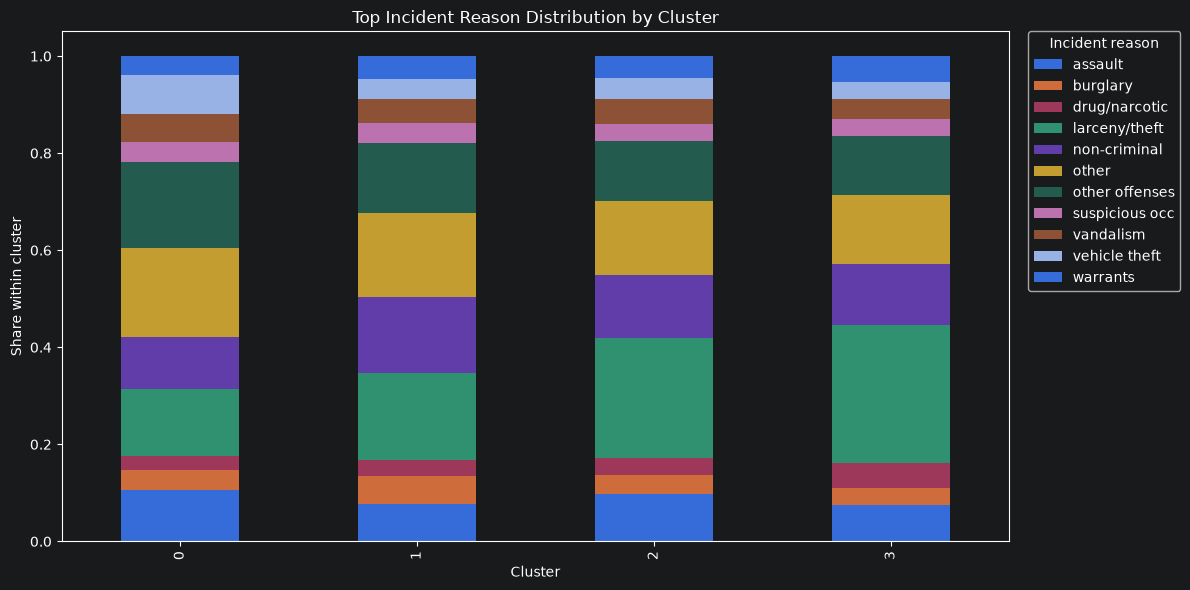

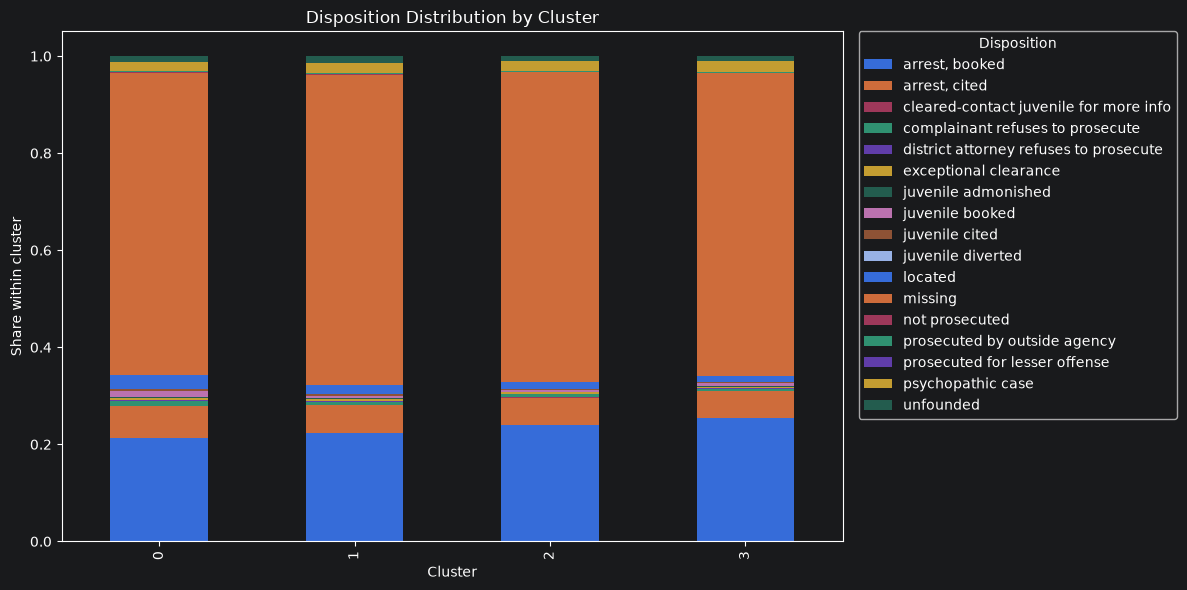

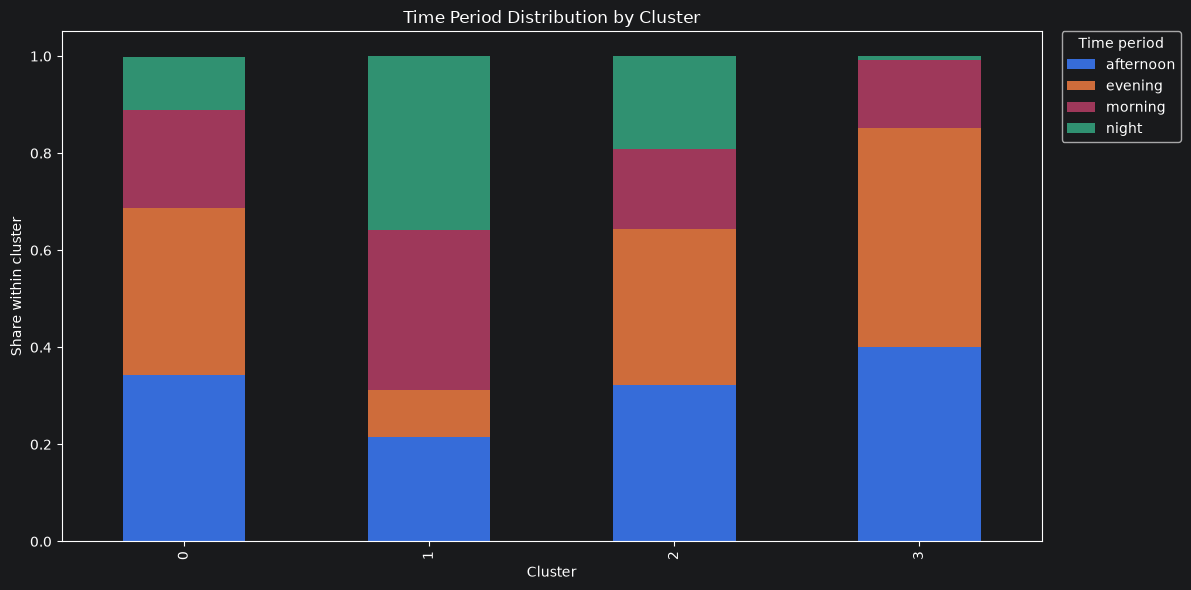

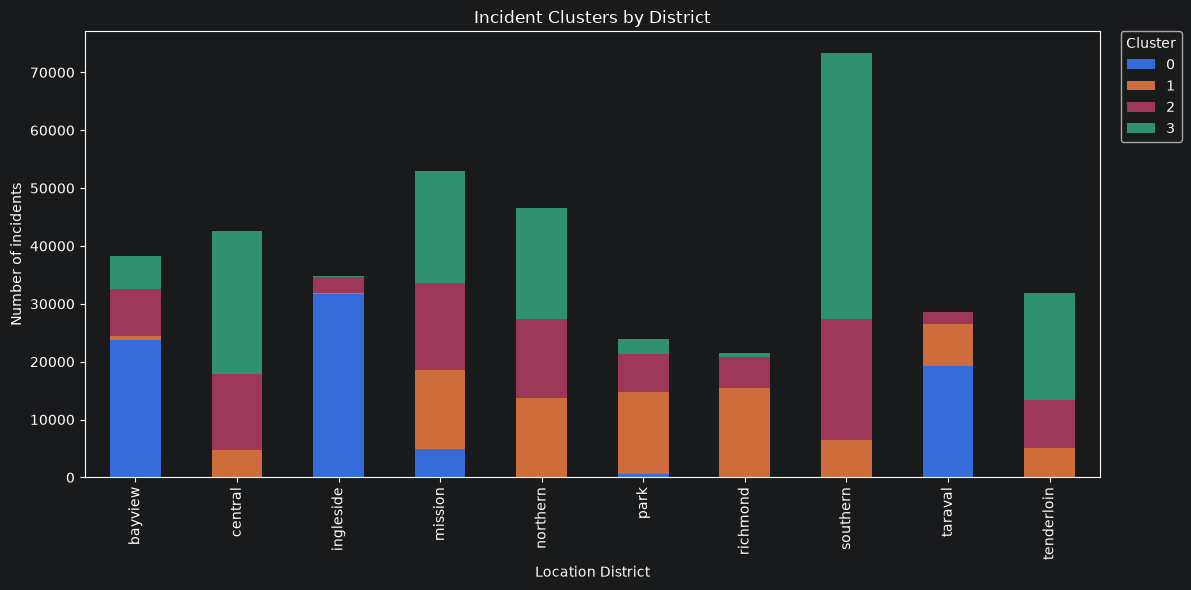

In [18]:
incident_reason_table = plot_stacked_distribution(
    df_clustered,
    row_col="cluster",
    category_col="incident_reason_simple",
    title="Top Incident Reason Distribution by Cluster",
    filename="incident_reason_by_cluster.png",
    top_n=10,
    legend_title="Incident reason",
)

disposition_table = plot_stacked_distribution(
    df_clustered,
    row_col="cluster",
    category_col="disposition_simple",
    title="Disposition Distribution by Cluster",
    filename="disposition_by_cluster.png",
    top_n=None,
    legend_title="Disposition",
)

time_period_table = plot_stacked_distribution(
    df_clustered,
    row_col="cluster",
    category_col="time_period",
    title="Time Period Distribution by Cluster",
    filename="time_period_by_cluster.png",
    top_n=None,
    legend_title="Time period",
)

cluster_district_table = plot_stacked_distribution(
    df_clustered,
    row_col="LOCATION_DISTRICT",
    category_col="cluster",
    title="Incident Clusters by District",
    filename="clusters_by_district.png",
    top_n=None,
    normalize=False,
    legend_title="Cluster",
)

## 10. Outputs

The most important files for the report are:

- `outputs/final_cluster_summary_for_report.csv`
- `outputs/cluster_counts.csv`
- `outputs/cluster_evaluation.csv`
- `outputs/figures/svd_clusters_2d.png`
- `outputs/figures/geographic_cluster_distribution.png`
- `outputs/figures/incidents_per_cluster.png`
- `outputs/figures/incident_reason_by_cluster.png`
- `outputs/figures/disposition_by_cluster.png`

The clusters reveal recurring patterns in policing activity. They do not by themselves prove causal explanations or discrimination.